Урок 33. Ансамблевые методы машинного обучения. Бустинг.

Сулейменова Инкара

In [10]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import shapiro

from collections import Counter

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

from imblearn.over_sampling import SMOTE

In [2]:
path = kagglehub.dataset_download("kanchana1990/nasa-exoplanet-archive-intelligence")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Админ\.cache\kagglehub\datasets\kanchana1990\nasa-exoplanet-archive-intelligence\versions\1


In [3]:
nasa_df = pd.read_csv(f'{path}/nasa_exoplanet_intelligence.csv')
nasa_df

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570000,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437000,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100000,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700000,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6145,KMT-2024-BLG-1870L b,KMT-2024-BLG-1870L,1,1,Microlensing,2026.0,KMTNet,NaN,13.800000,336.898111,...,272.465333,-26.882889,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6146,TOI-2267 b,TOI-2267 A,2,3,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),2.289090,1.000000,0.972000,...,65.061496,84.900824,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6147,TOI-813 b,TOI-813,1,1,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),83.891100,6.710000,36.400000,...,72.694010,-60.905461,0,Gas Giant,False,False,True,Mid(100-500pc),G-type(Sun-like),Medium(10-100d)
6148,LHS 1903 b,LHS 1903,1,4,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),2.155510,1.382000,3.280000,...,107.865826,48.327933,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)


In [5]:
nasa_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6150 entries, 0 to 6149
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   planet_name           6150 non-null   str    
 1   host_star             6150 non-null   str    
 2   n_stars               6150 non-null   int64  
 3   n_planets             6150 non-null   int64  
 4   discovery_method      6150 non-null   str    
 5   disc_year             6149 non-null   float64
 6   disc_facility         6150 non-null   str    
 7   orbital_period_days   5816 non-null   float64
 8   planet_radius_earth   6100 non-null   float64
 9   planet_mass_earth     6119 non-null   float64
 10  equilibrium_temp_k    4587 non-null   float64
 11  orbital_eccentricity  5212 non-null   float64
 12  semi_major_axis_au    5834 non-null   float64
 13  star_temp_k           5860 non-null   float64
 14  star_radius_sun       5836 non-null   float64
 15  star_mass_sun         6142 non-n

In [4]:
#Шаг 1 - Загрузка и исследование данн
#для показа всех колонок датасета
pd.set_option('display.max_columns', None)
nasa_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6150 entries, 0 to 6149
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   planet_name           6150 non-null   str    
 1   host_star             6150 non-null   str    
 2   n_stars               6150 non-null   int64  
 3   n_planets             6150 non-null   int64  
 4   discovery_method      6150 non-null   str    
 5   disc_year             6149 non-null   float64
 6   disc_facility         6150 non-null   str    
 7   orbital_period_days   5816 non-null   float64
 8   planet_radius_earth   6100 non-null   float64
 9   planet_mass_earth     6119 non-null   float64
 10  equilibrium_temp_k    4587 non-null   float64
 11  orbital_eccentricity  5212 non-null   float64
 12  semi_major_axis_au    5834 non-null   float64
 13  star_temp_k           5860 non-null   float64
 14  star_radius_sun       5836 non-null   float64
 15  star_mass_sun         6142 non-n

In [ ]:
nasa_df['planet_type'].value_counts()
#таргетная переменная будет planet type

In [7]:
#Шаг 2 - Поиск, удаление и заполнение пропущенных значений
nasa_df.isnull().sum()

planet_name                0
host_star                  0
n_stars                    0
n_planets                  0
discovery_method           0
disc_year                  1
disc_facility              0
orbital_period_days      334
planet_radius_earth       50
planet_mass_earth         31
equilibrium_temp_k      1563
orbital_eccentricity     938
semi_major_axis_au       316
star_temp_k              290
star_radius_sun          314
star_mass_sun              8
star_age_gyr            1311
star_surface_gravity     318
star_metallicity         550
dist_from_earth_pc        27
star_vmag                295
ra                         0
dec                        0
controversial_flag         0
planet_type                0
habitable_zone_flag        0
multi_planet_system        0
is_recent_discovery        0
dist_category              0
star_type                  0
orbital_period_cat         0
dtype: int64

for col in nasa_df.columns:
  if nasa_df[col].dtypes in ['int64', 'float64']:
    nasa_df[col].fillna(nasa_df[col].mean(), inplace=True)
  else:
    nasa_df[col].fillna(nasa_df[col].mode()[0], inplace=True)

первоначальная версия, написанного снизу кода. здесь несколько ошибок:
 
nasa[col] - возвращает копию, а не оригинал
"inplace=True" - пытается изменить копию

что ломает логику pandas работай с копией data[col], которая Series, а не DataFrame. pandas говорит, что не уверен, что изменение промежуточного объекта попадёт обратно в исходный DataFrame. А inplace=True пытается изменить именно результат этого промежуточного шага, а не явно сам nasa_df.

Поэтому правильный вариант:
nasa_df[col] = nasa_df[col].fillna(nasa_df[col].median())

Здесь уже всё однозначно:

- pandas берёт колонку
- создаёт обновлённую версию
- ты явно записываешь её обратно в оригинальный nasa_df


In [5]:
for col in nasa_df.columns:
   if nasa_df[col].dtypes in ['int64', 'float64']:
      nasa_df[col] = nasa_df[col].fillna(nasa_df[col].median())
   else:
      nasa_df[col] = nasa_df[col].fillna(nasa_df[col].mode()[0])

In [6]:
nasa_df.isnull().sum()

planet_name             0
host_star               0
n_stars                 0
n_planets               0
discovery_method        0
disc_year               0
disc_facility           0
orbital_period_days     0
planet_radius_earth     0
planet_mass_earth       0
equilibrium_temp_k      0
orbital_eccentricity    0
semi_major_axis_au      0
star_temp_k             0
star_radius_sun         0
star_mass_sun           0
star_age_gyr            0
star_surface_gravity    0
star_metallicity        0
dist_from_earth_pc      0
star_vmag               0
ra                      0
dec                     0
controversial_flag      0
planet_type             0
habitable_zone_flag     0
multi_planet_system     0
is_recent_discovery     0
dist_category           0
star_type               0
orbital_period_cat      0
dtype: int64

In [10]:
#Шаг 3 - Удаление ненужных столбцов (ID, имя и т.п.) 
nasa_df.nunique()

planet_name             6150
host_star               4582
n_stars                    4
n_planets                  8
discovery_method          11
disc_year                 34
disc_facility             73
orbital_period_days     5803
planet_radius_earth     2136
planet_mass_earth       2817
equilibrium_temp_k      1876
orbital_eccentricity     611
semi_major_axis_au      3537
star_temp_k             2296
star_radius_sun         1809
star_mass_sun           1206
star_age_gyr             662
star_surface_gravity    1250
star_metallicity         618
dist_from_earth_pc      4469
star_vmag               3220
ra                      4579
dec                     4579
controversial_flag         2
planet_type                7
habitable_zone_flag        2
multi_planet_system        2
is_recent_discovery        2
dist_category              5
star_type                  8
orbital_period_cat         6
dtype: int64

In [11]:
nasa_df = nasa_df.drop(columns=['planet_name'])

In [12]:
#Шаг 4 - Обнаружение и удаление дубликатов 
nasa_df.duplicated().sum()

np.int64(0)

In [ ]:
#Шаг 5 - Определения распределения признаков

In [7]:
nasa_num_df = nasa_df.select_dtypes(include=['int64', 'float64'])

In [28]:
nasa_num_df.nunique()

n_stars                    4
n_planets                  8
disc_year                 34
orbital_period_days     5803
planet_radius_earth     2136
planet_mass_earth       2817
equilibrium_temp_k      1876
orbital_eccentricity     611
semi_major_axis_au      3537
star_temp_k             2296
star_radius_sun         1809
star_mass_sun           1206
star_age_gyr             662
star_surface_gravity    1250
star_metallicity         618
dist_from_earth_pc      4469
star_vmag               3220
ra                      4579
dec                     4579
controversial_flag         2
dtype: int64

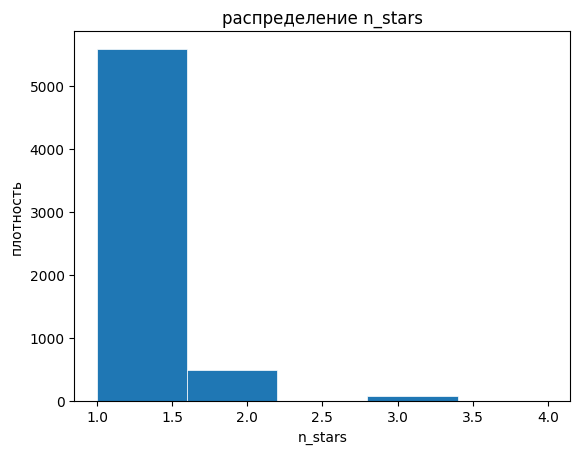

In [23]:
plt.hist(
   nasa_num_df['n_stars'],
   bins=5,
   edgecolor='white',
   linewidth=0.5
)
plt.title('распределение n_stars')
plt.xlabel('n_stars')
plt.ylabel('плотность')
plt.show()

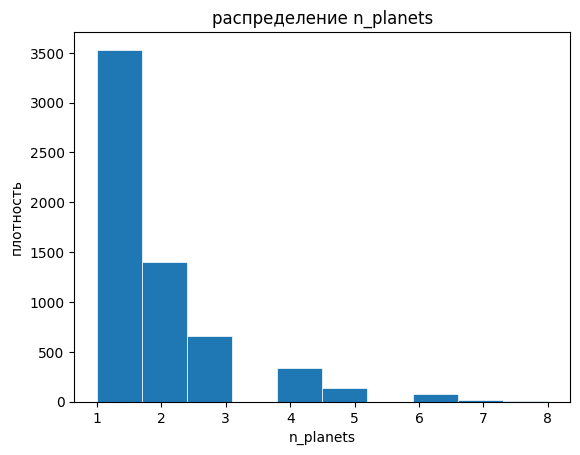

In [25]:
plt.hist(
   nasa_num_df['n_planets'],
   bins=10,
   edgecolor='white',
   linewidth=0.5)
plt.title('распределение n_planets')
plt.xlabel('n_planets')
plt.ylabel('плотность')
plt.show()

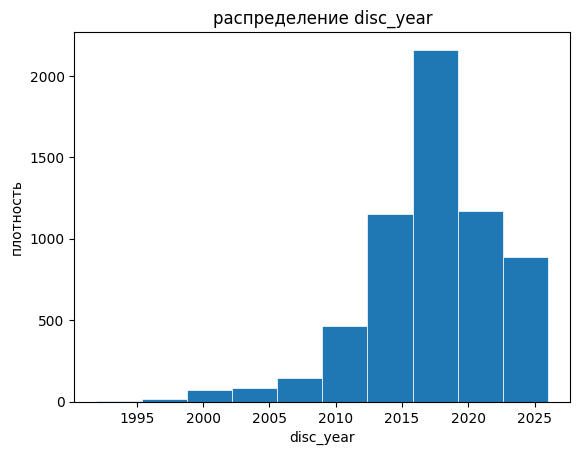

In [27]:
plt.hist(
   nasa_num_df['disc_year'],
   bins=10,
   edgecolor='white',
   linewidth=0.5)
plt.title('распределение disc_year')
plt.xlabel('disc_year')
plt.ylabel('плотность')
plt.show()

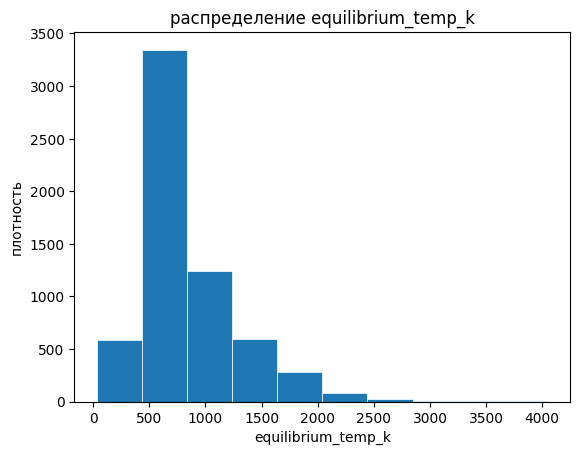

In [ ]:
plt.hist(
   nasa_num_df['equilibrium_temp_k'],
   bins=10,
   edgecolor='white',
   linewidth=0.5)
plt.title('распределение equilibrium_temp_k')
plt.xlabel('equilibrium_temp_k')
plt.ylabel('плотность')
plt.show()

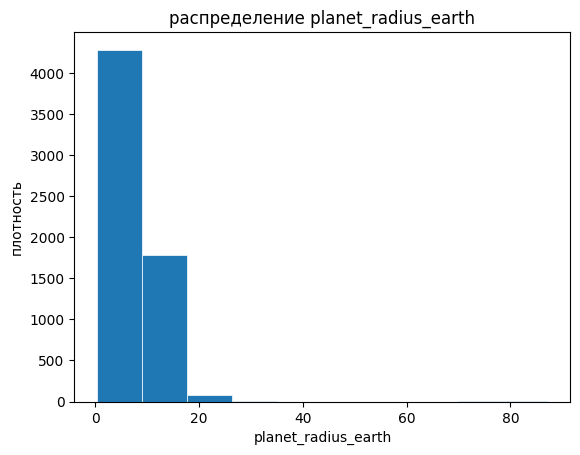

In [30]:
plt.hist(
   nasa_num_df['planet_radius_earth'],
   bins=10,
   edgecolor='white',
   linewidth=0.5)
plt.title('распределение planet_radius_earth')
plt.xlabel('planet_radius_earth')
plt.ylabel('плотность')
plt.show()

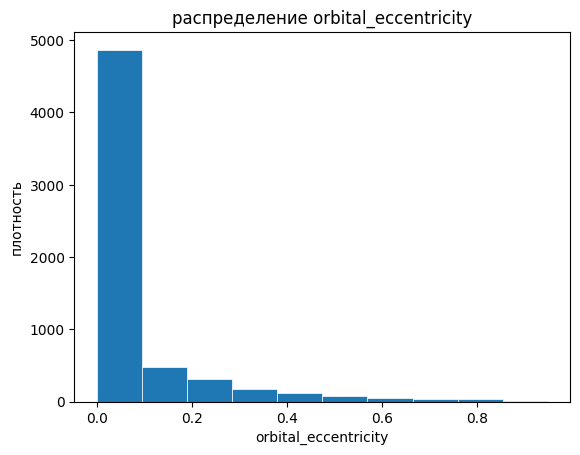

In [32]:
plt.hist(
   nasa_num_df['orbital_eccentricity'],
   bins=10,
   edgecolor='white',
   linewidth=0.5)
plt.title('распределение orbital_eccentricity')
plt.xlabel('orbital_eccentricity')
plt.ylabel('плотность')
plt.show()

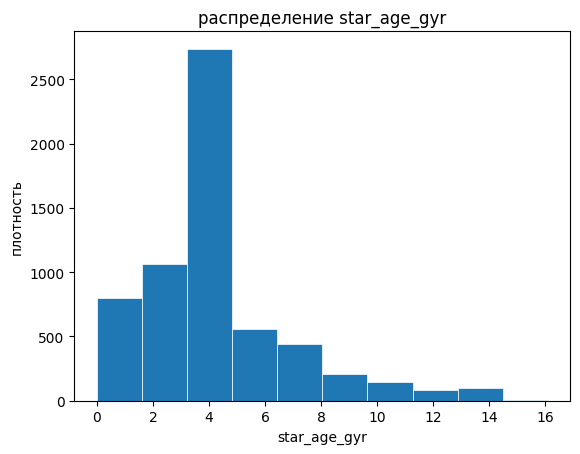

In [37]:
plt.hist(
   nasa_num_df['star_age_gyr'],
   bins=10,
   edgecolor='white',
   linewidth=0.5)
plt.title('распределение star_age_gyr')
plt.xlabel('star_age_gyr')
plt.ylabel('плотность')
plt.show()

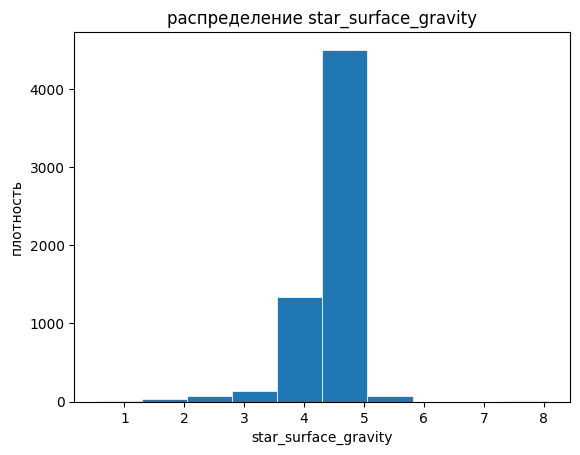

In [38]:
plt.hist(
   nasa_num_df['star_surface_gravity'],
   bins=10,
   edgecolor='white',
   linewidth=0.5)
plt.title('распределение star_surface_gravity')
plt.xlabel('star_surface_gravity')
plt.ylabel('плотность')
plt.show()

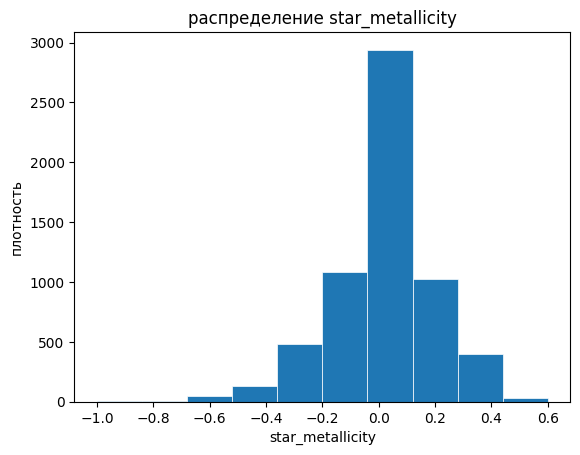

In [39]:
plt.hist(
   nasa_num_df['star_metallicity'],
   bins=10,
   edgecolor='white',
   linewidth=0.5)
plt.title('распределение star_metallicity')
plt.xlabel('star_metallicity')
plt.ylabel('плотность')
plt.show()

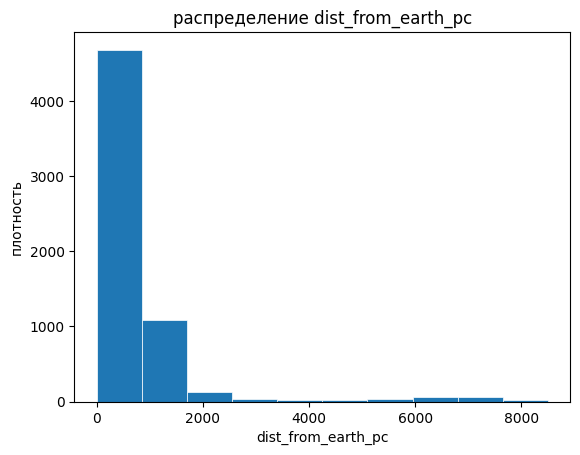

In [40]:
plt.hist(
   nasa_num_df['dist_from_earth_pc'],
   bins=10,
   edgecolor='white',
   linewidth=0.5)
plt.title('распределение dist_from_earth_pc')
plt.xlabel('dist_from_earth_pc')
plt.ylabel('плотность')
plt.show()

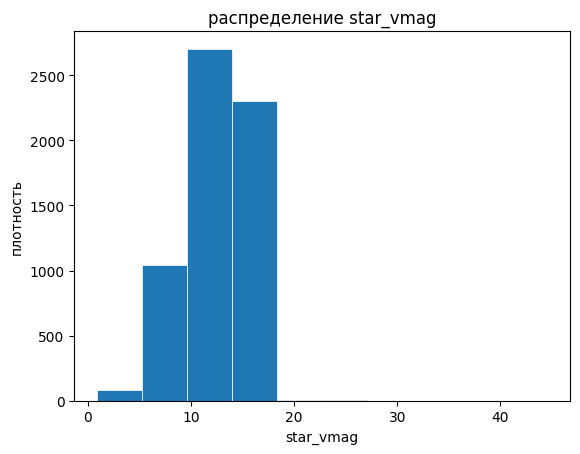

In [41]:
plt.hist(
   nasa_num_df['star_vmag'],
   bins=10,
   edgecolor='white',
   linewidth=0.5)
plt.title('распределение star_vmag')
plt.xlabel('star_vmag')
plt.ylabel('плотность')
plt.show()

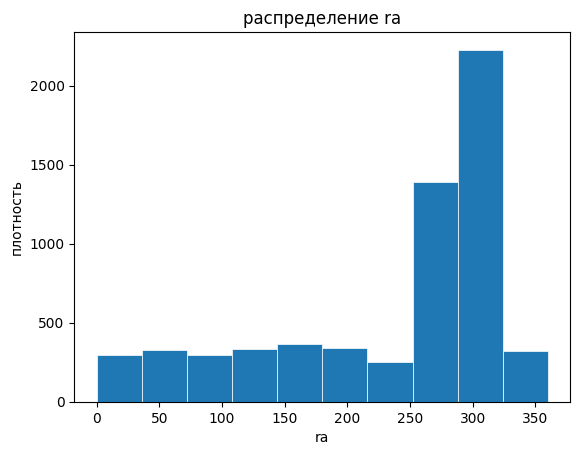

In [42]:
plt.hist(
   nasa_num_df['ra'],
   bins=10,
   edgecolor='white',
   linewidth=0.5)
plt.title('распределение ra')
plt.xlabel('ra')
plt.ylabel('плотность')
plt.show()

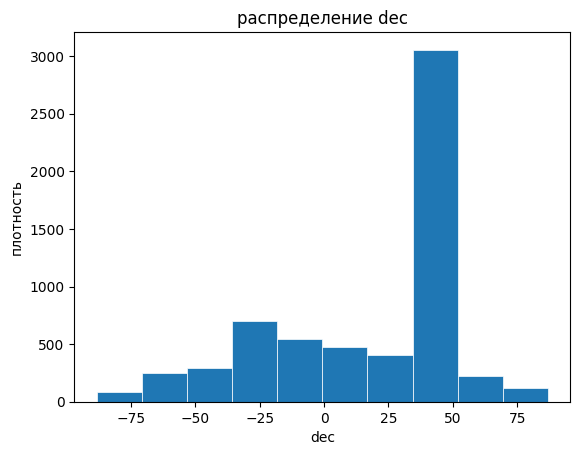

In [43]:
plt.hist(
   nasa_num_df['dec'],
   bins=10,
   edgecolor='white',
   linewidth=0.5)
plt.title('распределение dec')
plt.xlabel('dec')
plt.ylabel('плотность')
plt.show()

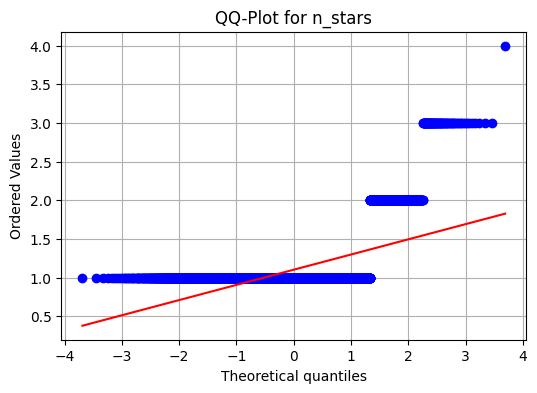

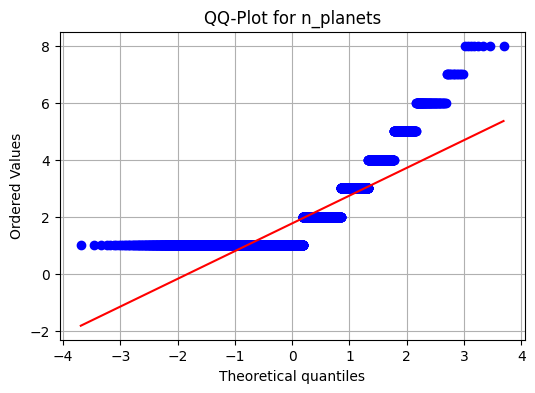

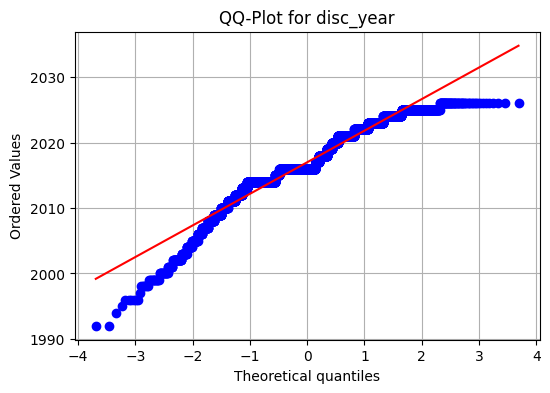

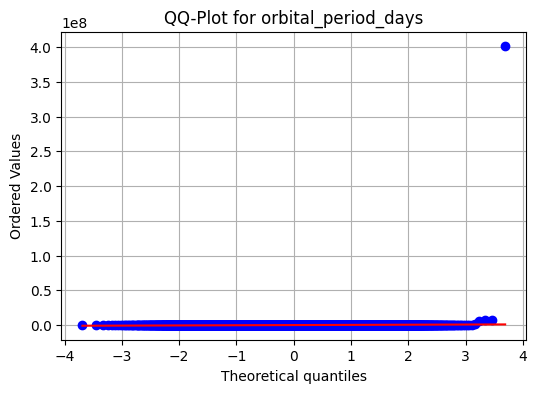

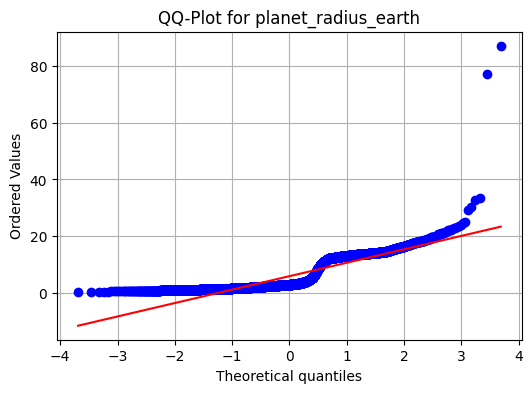

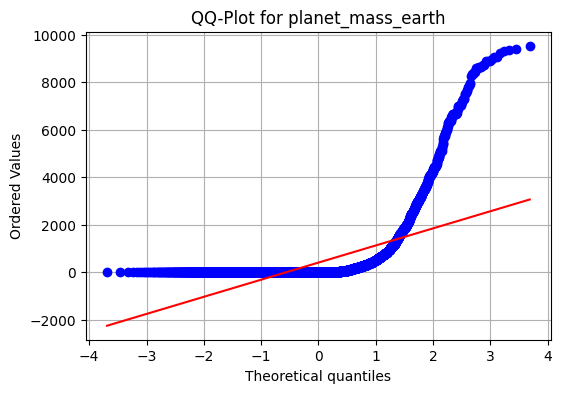

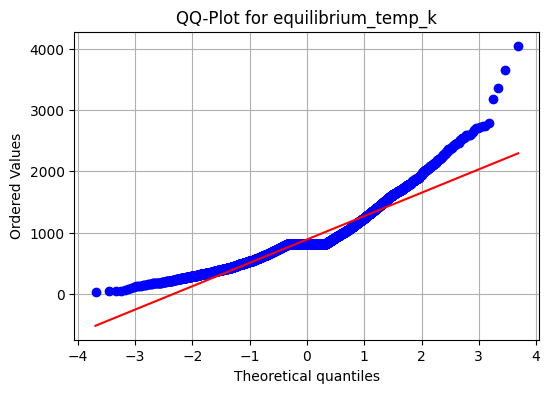

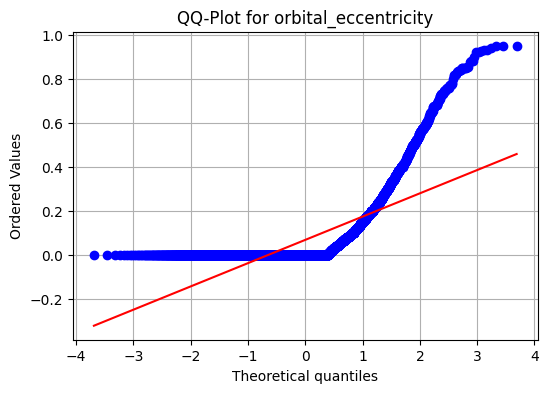

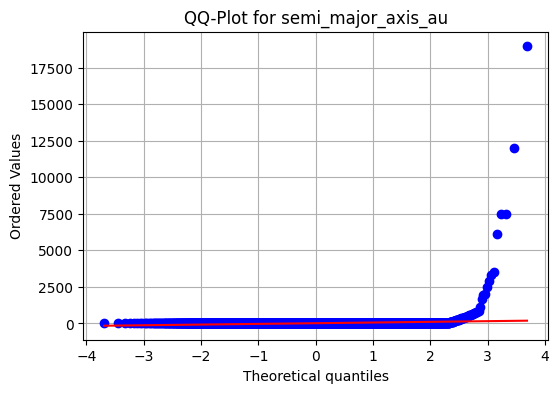

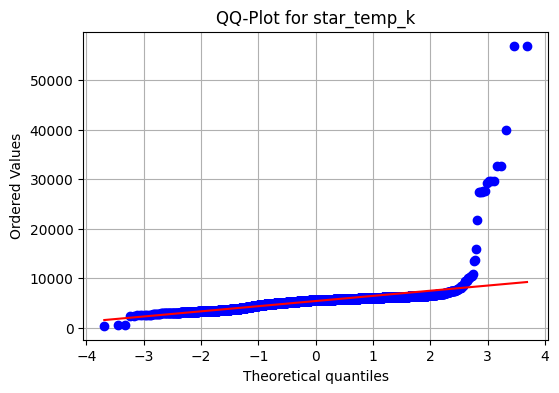

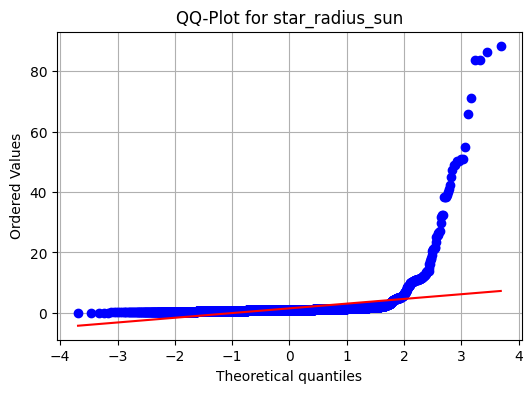

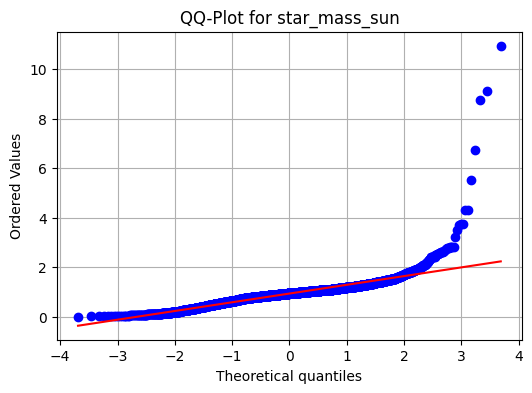

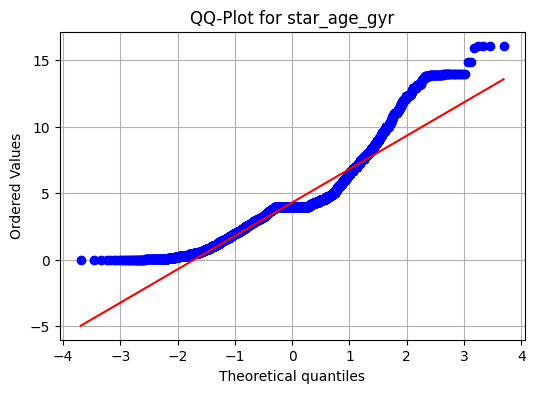

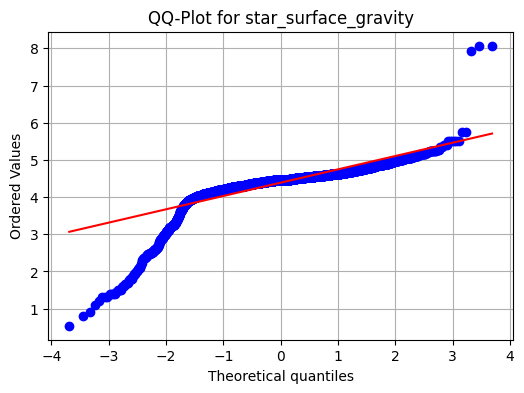

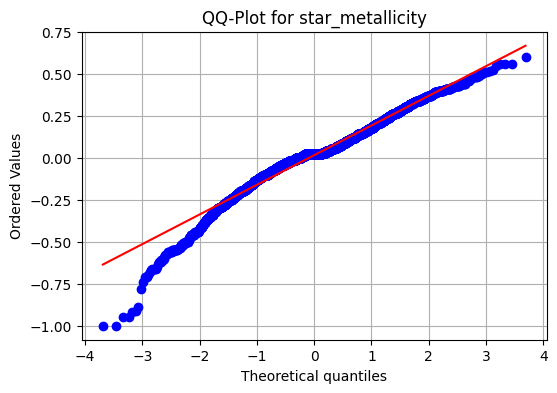

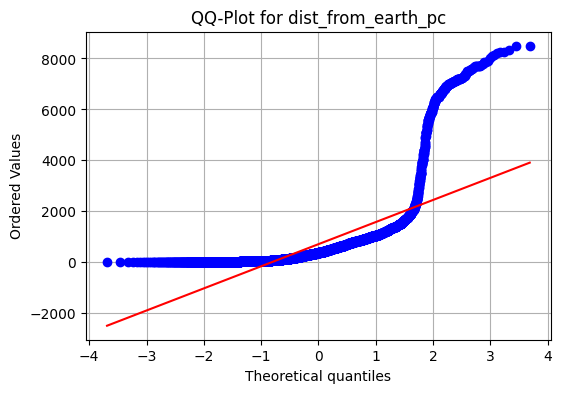

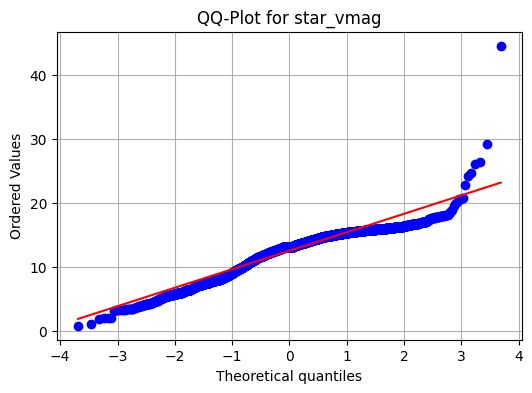

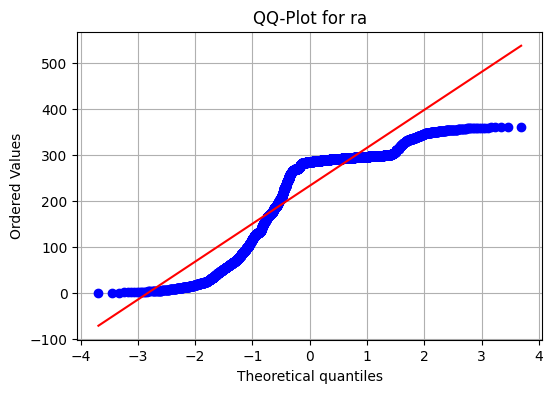

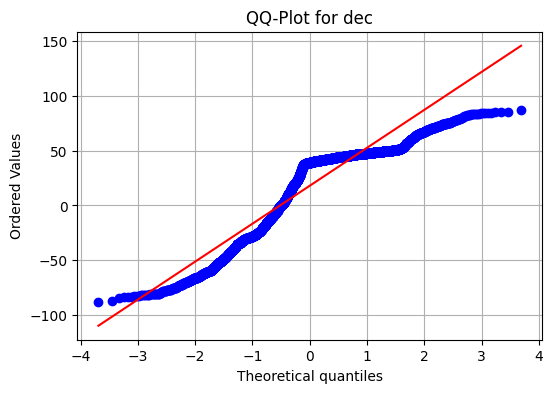

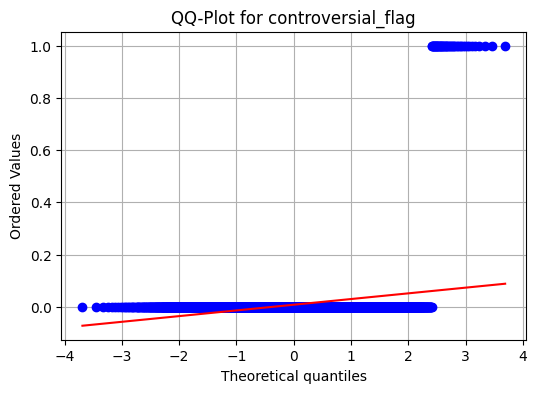

In [ ]:
numeric_columns = nasa_num_df.columns

for column in numeric_columns:
    plt.figure(figsize=(6, 4))
    stats.probplot(nasa_num_df[column], dist="norm", plot=plt)
    plt.title(f"QQ-Plot for {column}")
    plt.grid(True)
    plt.show()

In [11]:
for column in nasa_num_df.columns:
    stat, p = shapiro(nasa_num_df[column])
    
    print(f"{column}")
    print(f"Statistic: {stat:.4f}")
    print(f"p-value: {p:.4f}")
    
    if p > 0.05:
        print("Распределение похоже на нормальное")
    else:
        print("Распределение отличается от нормального")
    
    print("-" * 40)

n_stars
Statistic: 0.3277
p-value: 0.0000
Распределение отличается от нормального
----------------------------------------
n_planets
Statistic: 0.7041
p-value: 0.0000
Распределение отличается от нормального
----------------------------------------
disc_year
Statistic: 0.9459
p-value: 0.0000
Распределение отличается от нормального
----------------------------------------
orbital_period_days
Statistic: 0.0028
p-value: 0.0000
Распределение отличается от нормального
----------------------------------------
planet_radius_earth
Statistic: 0.7652
p-value: 0.0000
Распределение отличается от нормального
----------------------------------------
planet_mass_earth
Statistic: 0.3990
p-value: 0.0000
Распределение отличается от нормального
----------------------------------------
equilibrium_temp_k
Statistic: 0.8947
p-value: 0.0000
Распределение отличается от нормального
----------------------------------------
orbital_eccentricity
Statistic: 0.5429
p-value: 0.0000
Распределение отличается от нормаль

d:\Anaconda3\envs\ozenvision\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6150.
  res = hypotest_fun_out(*samples, **kwds)


In [12]:
df_num = nasa_num_df.drop(columns=['n_stars', 'n_planets', 'controversial_flag', 'disc_year'])

In [13]:
df_num.columns

Index(['orbital_period_days', 'planet_radius_earth', 'planet_mass_earth',
       'equilibrium_temp_k', 'orbital_eccentricity', 'semi_major_axis_au',
       'star_temp_k', 'star_radius_sun', 'star_mass_sun', 'star_age_gyr',
       'star_surface_gravity', 'star_metallicity', 'dist_from_earth_pc',
       'star_vmag', 'ra', 'dec'],
      dtype='str')

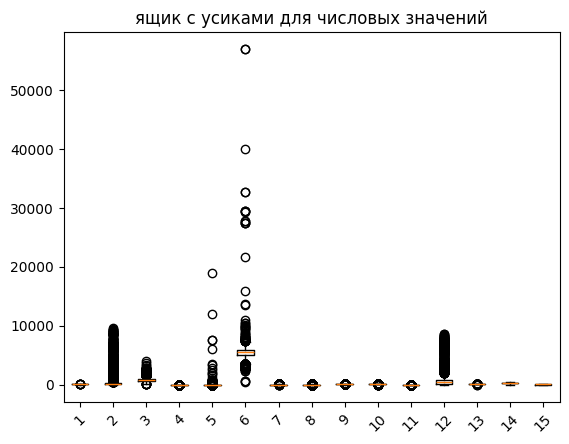

In [14]:
plt.boxplot(df_num[['planet_radius_earth', 'planet_mass_earth',
       'equilibrium_temp_k', 'orbital_eccentricity', 'semi_major_axis_au',
       'star_temp_k', 'star_radius_sun', 'star_mass_sun', 'star_age_gyr',
       'star_surface_gravity', 'star_metallicity', 'dist_from_earth_pc',
       'star_vmag', 'ra', 'dec']])
plt.title('ящик с усиками для числовых значений')
plt.xticks(rotation=45)
plt.show()

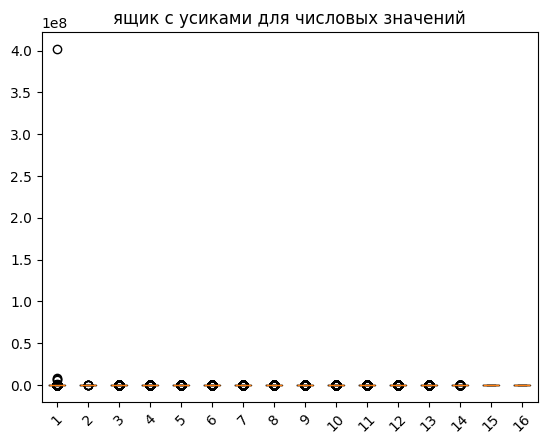

In [15]:
plt.boxplot(df_num)
plt.title('ящик с усиками для числовых значений')
plt.xticks(rotation=45)
plt.show()

In [16]:
q1 = df_num.quantile(0.25)
q3 = df_num.quantile(0.75)

iqr = q3 - q1

upper_b = q3 + 1.5 * iqr
lower_b = q1 - 1.5 * iqr

noise = (lower_b > df_num) | (upper_b < df_num)
noise_idx = df_num[noise.sum(axis=1) >= 2].index
noise_idx.shape

(1833,)

In [17]:
nasa_df.shape

(6150, 31)

In [18]:
nasa_df = nasa_df.drop(index=noise_idx)
nasa_df.shape

(4317, 31)

<Axes: >

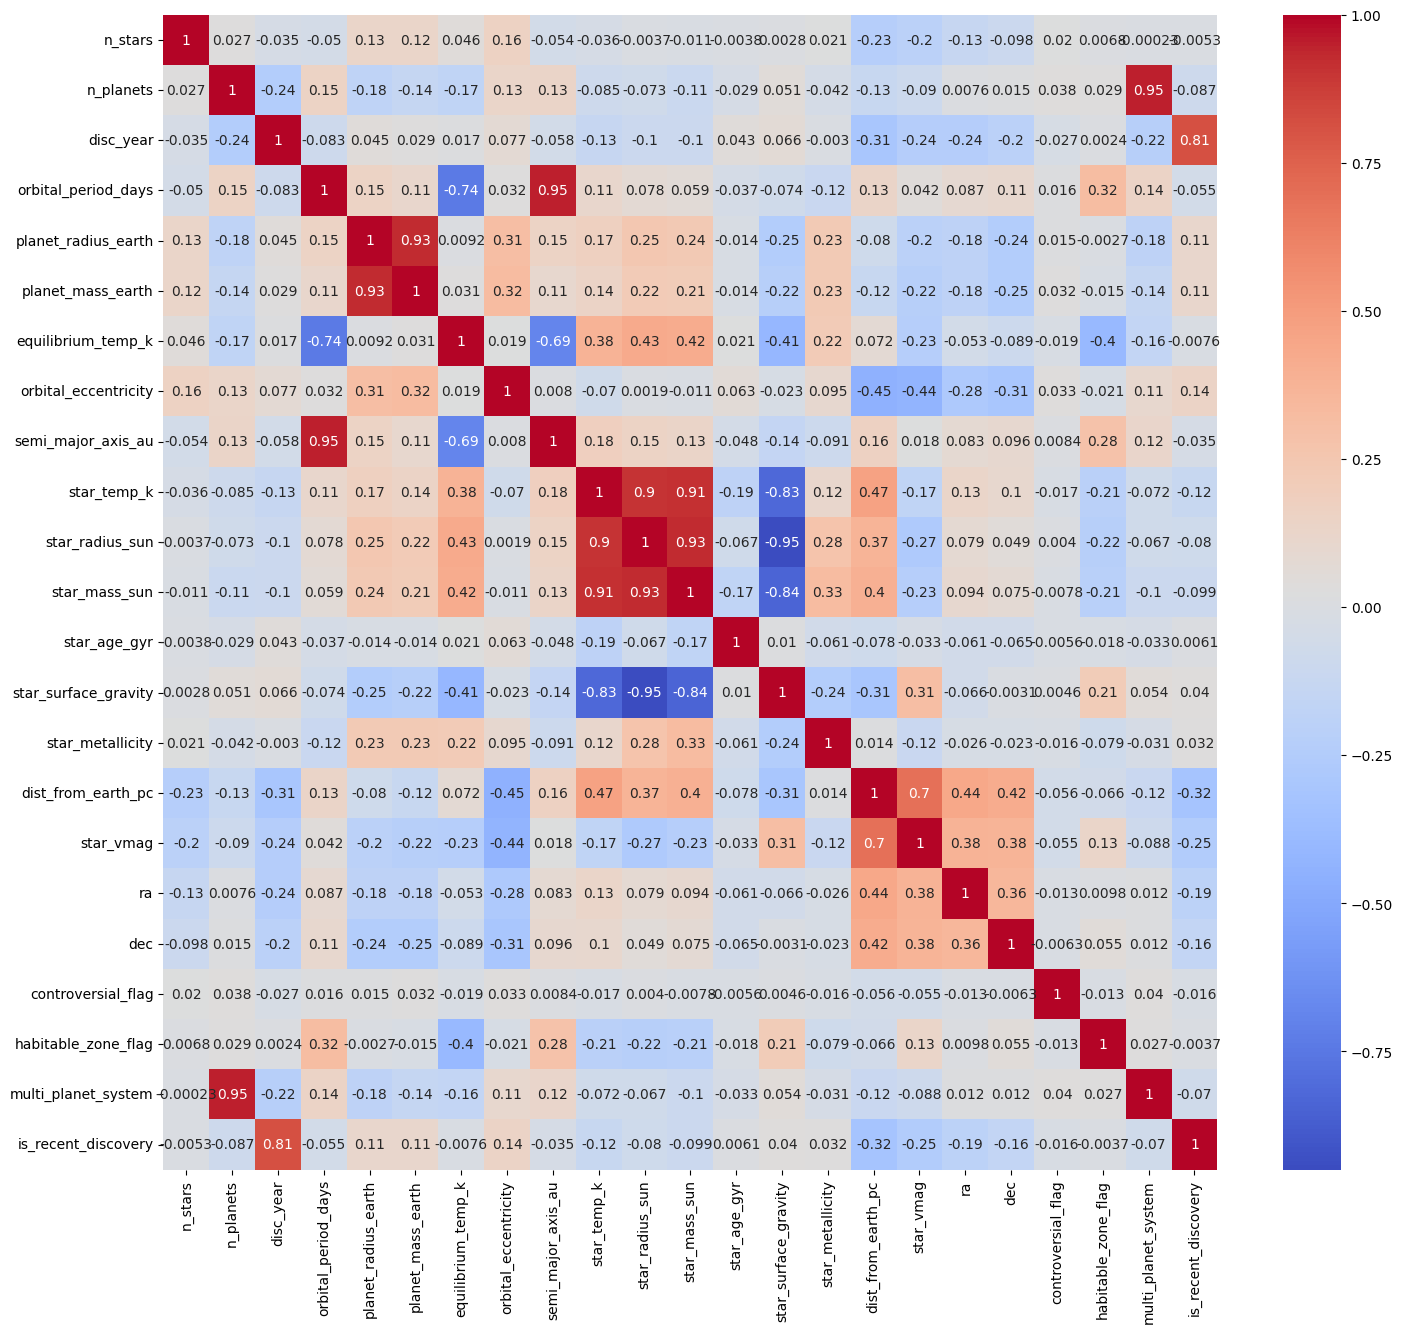

In [19]:
plt.figure(figsize=(17,15))
sns.heatmap(nasa_df.corr(method='spearman', numeric_only=True), cmap='coolwarm', annot=True)

In [20]:
nasa_df.columns

Index(['planet_name', 'host_star', 'n_stars', 'n_planets', 'discovery_method',
       'disc_year', 'disc_facility', 'orbital_period_days',
       'planet_radius_earth', 'planet_mass_earth', 'equilibrium_temp_k',
       'orbital_eccentricity', 'semi_major_axis_au', 'star_temp_k',
       'star_radius_sun', 'star_mass_sun', 'star_age_gyr',
       'star_surface_gravity', 'star_metallicity', 'dist_from_earth_pc',
       'star_vmag', 'ra', 'dec', 'controversial_flag', 'planet_type',
       'habitable_zone_flag', 'multi_planet_system', 'is_recent_discovery',
       'dist_category', 'star_type', 'orbital_period_cat'],
      dtype='str')

In [21]:
nasa_df = nasa_df.drop(columns=['orbital_period_days', 'multi_planet_system', 'star_surface_gravity'])

In [22]:
nasa_df['planet_type'].value_counts()

planet_type
Mini-Neptune     1967
Super-Earth      1050
Gas Giant         558
Neptune-like      378
Sub-Earth         198
Super-Jupiter     147
Unknown            19
Name: count, dtype: int64

In [73]:
le = LabelEncoder()

for col in nasa_df.columns:
   if nasa_df[col].dtypes in ['str']: 
      nasa_df[col] = le.fit_transform(nasa_df[col])

nasa_df

,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,planet_radius_earth,planet_mass_earth,equilibrium_temp_k,orbital_eccentricity,semi_major_axis_au,star_temp_k,star_radius_sun,star_mass_sun,star_age_gyr,star_metallicity,dist_from_earth_pc,star_vmag,ra,dec,controversial_flag,planet_type,habitable_zone_flag,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,926,1,1,5,2016.0,22,1.710000,3.57000,1419.0,0.0000,0.01750,4971.00,0.75000,0.790,4.27,-0.05,820.9050,16.0470,298.302660,47.693965,0,4,False,False,1,2,2
1,1518,1,1,5,2021.0,22,3.323214,11.00000,858.0,0.0000,0.07790,5705.00,0.90500,0.943,3.98,-0.06,1061.7700,15.4540,293.873663,38.922455,0,1,False,True,1,1,2
2,1371,1,1,5,2016.0,22,0.800000,0.43700,1108.0,0.0000,0.06865,6022.00,1.23000,1.120,4.17,0.07,493.1750,12.4420,287.371320,39.603623,0,3,False,False,2,0,2
3,2226,1,1,5,2016.0,22,3.150000,10.10000,1655.0,0.0000,0.04641,6747.00,1.81000,1.490,1.62,0.08,1318.0500,14.0310,295.475702,43.493112,0,1,False,False,1,0,2
4,1529,1,1,5,2021.0,22,4.540605,18.70000,419.0,0.0000,0.26980,5446.00,0.82100,0.824,7.20,-0.20,962.8880,16.0249,290.854140,51.222743,0,2,False,True,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6136,3020,1,1,5,2026.0,45,3.710000,13.30000,872.0,0.0000,0.02870,4080.00,0.56400,0.583,3.98,-0.11,184.1200,14.1610,299.513133,55.651029,0,2,False,True,2,2,2
6139,568,3,2,5,2019.0,16,11.276254,246.00042,676.0,0.0000,0.30500,6302.00,1.51100,1.194,4.00,-0.06,272.9090,11.1140,234.857885,-20.198898,0,0,False,False,2,0,1
6141,33,1,1,4,2026.0,32,9.130000,61.39000,818.0,0.1000,0.05873,5996.82,1.53949,1.090,3.87,0.02,101.3860,8.7900,203.528465,0.498813,0,0,False,True,2,1,2
6144,3050,3,4,5,2019.0,16,6.530000,6.00000,831.0,0.0087,0.10810,4970.00,1.32000,1.100,0.02,0.10,108.1990,10.1150,61.331654,20.157032,0,0,False,False,2,2,1


In [74]:
bool_columns = nasa_df.select_dtypes(include='bool').columns

nasa_df[bool_columns] = nasa_df[bool_columns].astype(int)

In [75]:
X = nasa_df.drop(columns=['planet_type'])
y = nasa_df['planet_type']

In [76]:
nasa_df['planet_type'].value_counts()

planet_type
1    1967
4    1050
0     558
2     378
3     198
5     147
6      19
Name: count, dtype: int64

In [78]:
scaler = MinMaxScaler()
x_norm = scaler.fit_transform(X)

X = pd.DataFrame(x_norm, columns=X.columns)
X

,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,planet_radius_earth,planet_mass_earth,equilibrium_temp_k,orbital_eccentricity,semi_major_axis_au,star_temp_k,star_radius_sun,star_mass_sun,star_age_gyr,star_metallicity,dist_from_earth_pc,star_vmag,ra,dec,controversial_flag,habitable_zone_flag,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,0.290100,0.0,0.000000,0.833333,0.705882,0.448980,0.048249,0.000399,0.412762,0.000000,0.006106,0.481452,0.102041,0.417219,0.286577,0.596026,0.116193,0.769836,0.828588,0.776168,0.0,0.0,0.0,0.25,0.50,0.4
1,0.475564,0.0,0.000000,0.833333,0.852941,0.448980,0.103839,0.001234,0.226321,0.000000,0.034256,0.678763,0.133673,0.518543,0.267114,0.589404,0.150423,0.731638,0.816278,0.726040,0.0,0.0,1.0,0.25,0.25,0.4
2,0.429511,0.0,0.000000,0.833333,0.705882,0.448980,0.016892,0.000047,0.309405,0.000000,0.029945,0.763978,0.200000,0.635762,0.279866,0.675497,0.069619,0.537623,0.798205,0.729933,0.0,0.0,0.0,0.50,0.00,0.4
3,0.697368,0.0,0.000000,0.833333,0.705882,0.448980,0.097870,0.001133,0.491193,0.000000,0.019580,0.958871,0.318367,0.880795,0.108725,0.682119,0.186843,0.639977,0.820730,0.752161,0.0,0.0,0.0,0.25,0.00,0.4
4,0.479010,0.0,0.000000,0.833333,0.852941,0.448980,0.145788,0.002099,0.080425,0.000000,0.123695,0.609140,0.116531,0.439735,0.483221,0.496689,0.136371,0.768412,0.807885,0.796335,0.0,0.0,1.0,0.25,0.25,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4312,0.946115,0.0,0.000000,0.833333,1.000000,0.918367,0.117167,0.001492,0.230974,0.000000,0.011326,0.241935,0.064082,0.280132,0.267114,0.556291,0.025699,0.648351,0.831952,0.821642,0.0,0.0,1.0,0.50,0.50,0.4
4313,0.177945,1.0,0.142857,0.833333,0.794118,0.326531,0.377890,0.027641,0.165836,0.000000,0.140101,0.839247,0.257347,0.684768,0.268456,0.589404,0.038316,0.452081,0.652249,0.388168,0.0,0.0,0.0,0.50,0.00,0.2
4314,0.010338,0.0,0.000000,0.666667,1.000000,0.653061,0.303933,0.006896,0.213028,0.107643,0.025322,0.757210,0.263161,0.615894,0.259732,0.642384,0.013941,0.302382,0.565172,0.506453,0.0,0.0,1.0,0.50,0.25,0.4
4315,0.955514,1.0,0.428571,0.833333,0.794118,0.326531,0.214340,0.000672,0.217348,0.009365,0.048331,0.481183,0.218367,0.622517,0.001342,0.695364,0.014909,0.387731,0.169950,0.618798,0.0,0.0,0.0,0.50,0.50,0.2


In [80]:
smote = SMOTE()
X, y = smote.fit_resample(X, y)

In [82]:
Counter(y)

Counter({4: 1967, 1: 1967, 3: 1967, 2: 1967, 0: 1967, 5: 1967, 6: 1967})

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
parameters = {'n_estimators': [100, 200, 300],        #количество деревьев
    'learning_rate': [0.01, 0.05, 0.1],    # скорость обучения
    'max_depth': [3, 5, 7]}                # глубина деревьев
dt = GradientBoostingClassifier()
clf = GridSearchCV(dt, parameters)
clf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

In [87]:
clf = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42).fit(X_train, y_train)

In [88]:
y_pred = clf.predict(X_test)

In [91]:
print('Accurace score: ', accuracy_score(y_test, y_pred))
print('Classification report:\n', classification_report(y_test, y_pred))

Accurace score:  1.0
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       384
           1       1.00      1.00      1.00       412
           2       1.00      1.00      1.00       382
           3       1.00      1.00      1.00       398
           4       1.00      1.00      1.00       412
           5       1.00      1.00      1.00       371
           6       1.00      1.00      1.00       395

    accuracy                           1.00      2754
   macro avg       1.00      1.00      1.00      2754
weighted avg       1.00      1.00      1.00      2754



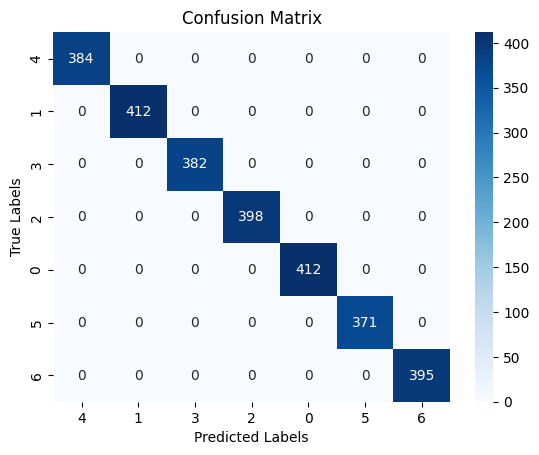

In [92]:
cm = confusion_matrix(y_test, y_pred)
labels = list(nasa_df['planet_type'].unique())

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()